In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats 
warnings.filterwarnings('ignore')



In [3]:
#Creating database connection
conn = sqlite3.connect('inventory.db')

#fetching vendor summary data
df = pd.read_sql("select * from vendor_sales_summary",conn)

df.head()

,vendornumber,description,vendorname,brand,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalSalesTax,freightcost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,Jack Daniels No 7 Black,BROWN-FORMAN CORP,1233,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,Tito's Handmade Vodka,MARTIGNETTI COMPANIES,3405,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,Absolut 80 Proof,PERNOD RICARD USA,8068,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,Capt Morgan Spiced Rum,DIAGEO NORTH AMERICA INC,4261,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,Ketel One Vodka,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [5]:
    df.head()

,vendornumber,description,vendorname,brand,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalSalesTax,freightcost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,Jack Daniels No 7 Black,BROWN-FORMAN CORP,1233,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,Tito's Handmade Vodka,MARTIGNETTI COMPANIES,3405,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,Absolut 80 Proof,PERNOD RICARD USA,8068,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,Capt Morgan Spiced Rum,DIAGEO NORTH AMERICA INC,4261,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,Ketel One Vodka,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [12]:
# Summary staistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendornumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
purchaseprice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


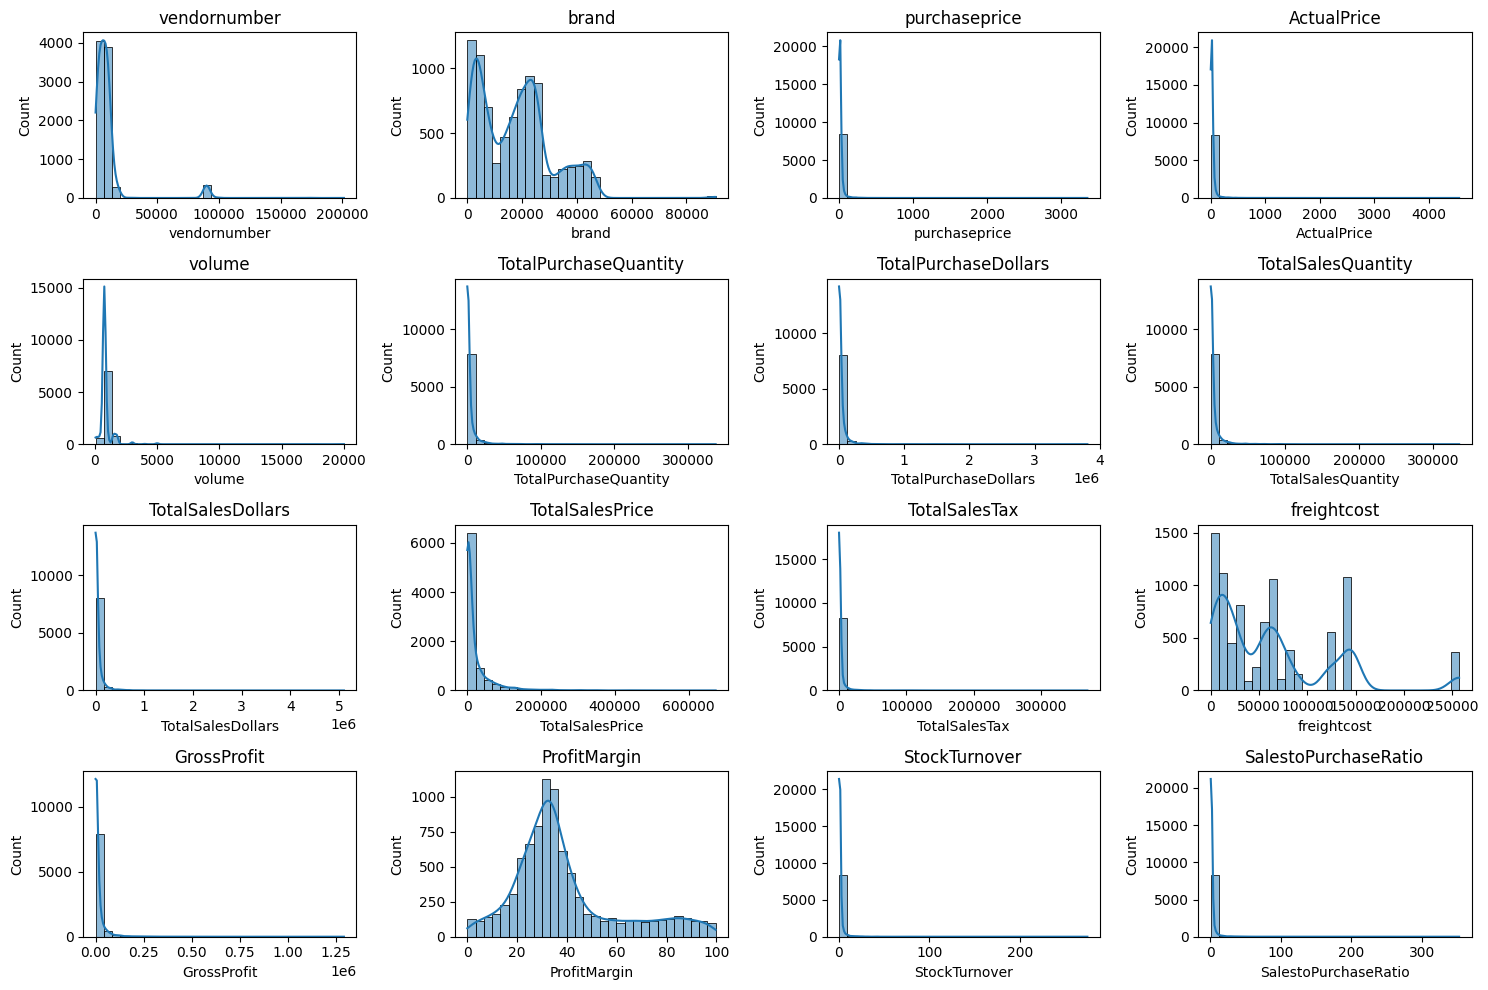

In [28]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include  = np.number).columns

plt.figure(figsize= (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) # Adjust grid layout as needed 
    sns.histplot(df[col],kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

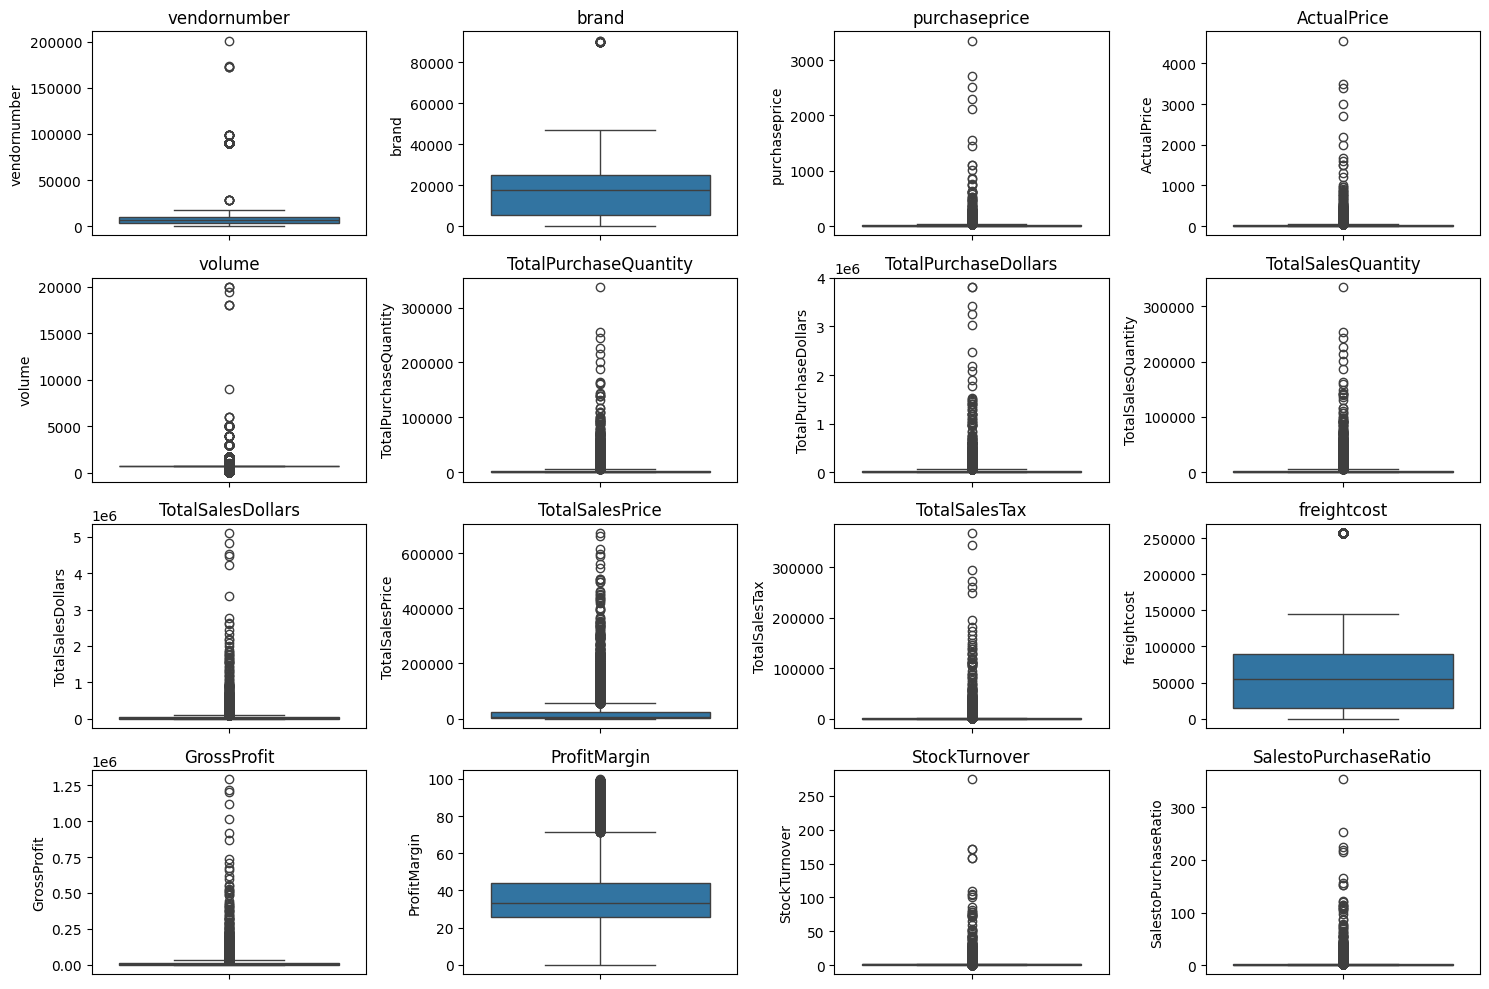

In [27]:
plt.figure(figsize= (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) # Adjust grid layout as needed 
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [24]:
# Filtering data to remove inconsistencies
df = pd.read_sql("""select * from vendor_sales_summary
                  where TotalSalesPrice > 0 and
                  GrossProfit > 0 and
                  TotalSalesQuantity > 0 """,conn)



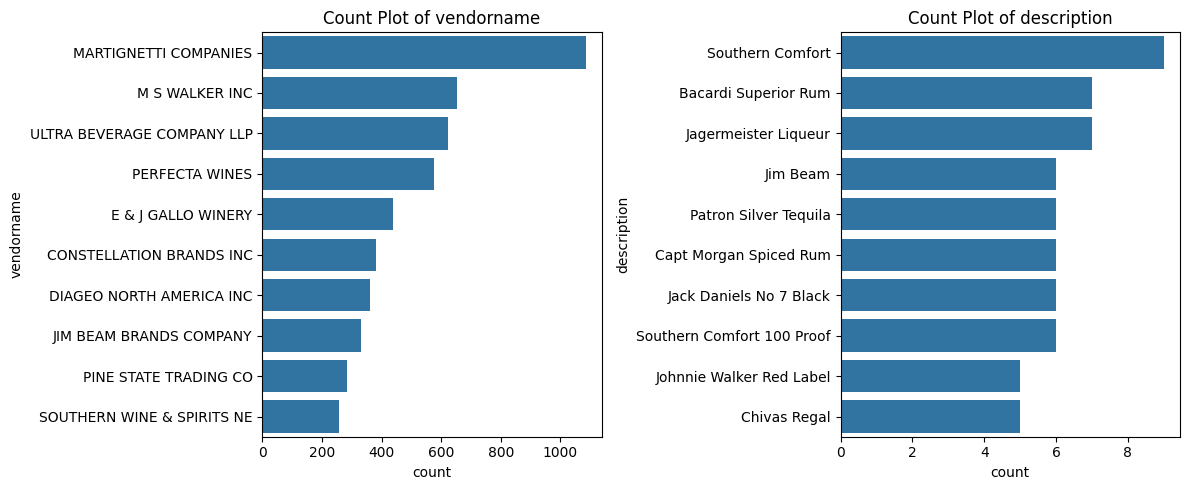

In [30]:
categorical_cols  = ["vendorname","description"]

plt.figure(figsize=(12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot( y=df[col], order = df[col].value_counts().index[:10])  # Top 10 categories 
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

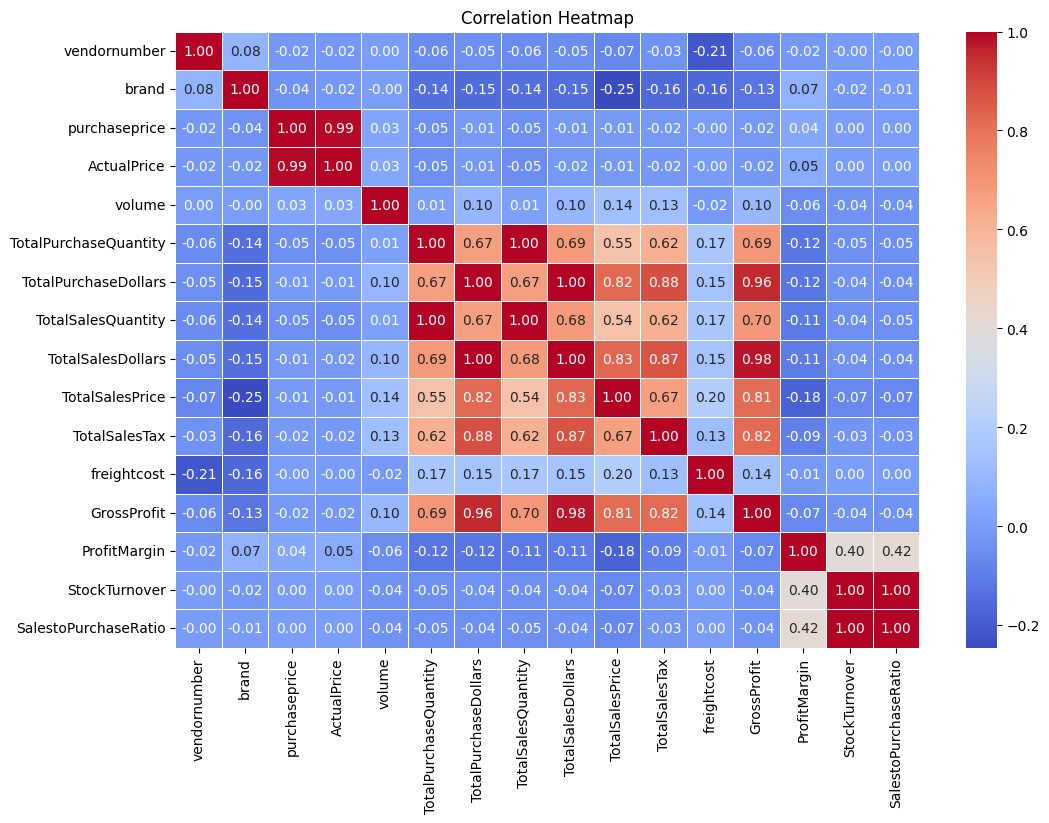

In [32]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot = True, fmt = ".2f",cmap ="coolwarm",linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.show()
           

In [35]:
# Correlation Insights 

# Data Analysis

### Identify Brands that need Promotional or Pricing Adjustments which exhibit lower sales performace but higher profit margins.
    

In [38]:
brand_performance = df.groupby('description').agg({'TotalSalesDollars' : 'sum',
                               'ProfitMargin' : 'mean'}).reset_index()

In [47]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)



In [49]:
target_brand = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold )]


print("Brands with Low Sales but High Profit Margins : ")
target_brand.sort_values('TotalSalesDollars')


Brands with Low Sales but High Profit Margins : 


,description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


### Which vendors and brands demonstrate the highest sales performance ?

In [62]:
def format_dollars(value):
    if value >= 1000000:
        return f"{value / 1000000 :.2f}M"
    elif value >= 1000:
       return f"{value / 1000:.2f}K"
    else:
       return str(value)


In [65]:
top_brands =df.groupby("description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors  = df.groupby("vendorname")["TotalSalesDollars"].sum().nlargest(10)
top_vendors.apply(format_dollars)

vendorname
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

In [63]:
top_brands.apply(format_dollars)

description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

### Which vendors contribute the most to the total purchase dollars ?


In [77]:
# Creating a new column to calculate vendor wise purchase contribution

vendor_performance["Purchase_contribution"]  = vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum() 

In [70]:
vendor_performance = df.groupby("vendorname").agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit' : 'sum',
    'TotalSalesDollars' : 'sum' }).reset_index()
    

In [89]:
top_vendors = round(vendor_performance.sort_values('Purchase_contribution',ascending = False),2)
top_vendors["TotalPurchaseDollars"] = top_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_vendors["GrossProfit"] = top_vendors["GrossProfit"].apply(format_dollars)
top_vendors["TotalSalesDollars"] = top_vendors["TotalSalesDollars"].apply(format_dollars)


top_vendors.head(10)

,vendorname,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_contribution
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03


### How much of total procurement is dependent on the top vendors?

In [98]:
Total_procurement  = top_vendors['Purchase_contribution'][:10].sum()

print("Total Purchase Contribution of Top 10 vendors is", round(Total_procurement,3)*100)

Total Purchase Contribution of Top 10 vendors is 66.0


### Does purchaseing in buld reduce the unit price, and what is the optimal purchase volume for cost savings? 

In [100]:
df["UntiPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

In [105]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"],q = 3,labels = ["Small","Medium","Large"])


In [107]:
df.groupby("OrderSize")["UntiPurchasePrice"].mean()

OrderSize
Small     39.068186
Medium    15.486414
Large     10.777625
Name: UntiPurchasePrice, dtype: float64

### Which vendors have low inventory turnover, indicating excess stock and slow-moving products ?


In [116]:
df[df['StockTurnover'] < 1].groupby("vendorname")[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
vendorname,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


### How much capital is locked in unsold inventory per vendor, and which vendors contribute to the most to it ?

In [128]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"]- df["TotalSalesQuantity"])* df["purchaseprice"]

print('Total Unsold Capital"',format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital" 2.71M


In [133]:
# Aggregated Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("vendorname")["UnsoldInventoryValue"].sum().reset_index()


# Sort Vendors with highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by= "UnsoldInventoryValue",ascending = False)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)

,vendorname,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [138]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [139]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [141]:
# Function to calculate confidence interval

def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [143]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


### Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [145]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


### Downloading data to create dashboard


In [156]:
data  = pd.read_sql("select * from vendor_sales_summary", conn)

In [159]:
data.to_excel("Vendor_sales_summary.xlsx", index = False)

In [163]:
hum = pd.read_sql("select * from vendor_sales_summary", conn)
hum.shape

(10692, 18)